# Homework 2: Stochastic Gradient Descent

## Exercise 1: SGD vs GD on a Simple 1D Regression Problem

Consider the synthetic dataset

$$
x^{(i)} = \frac{i}{N},\qquad
y^{(i)} = 2x^{(i)} + 1 + \varepsilon^{(i)}, \qquad \varepsilon^{(i)}\sim\mathcal N(0,0.01),
$$

with $N = 200$.
We model the data with a linear function:

$$
f_\Theta(x) = \Theta_0 + \Theta_1 x = \Theta^T \tilde{x},
$$

if we define $\tilde{x} = [1, x]$ as we did during the lab session.


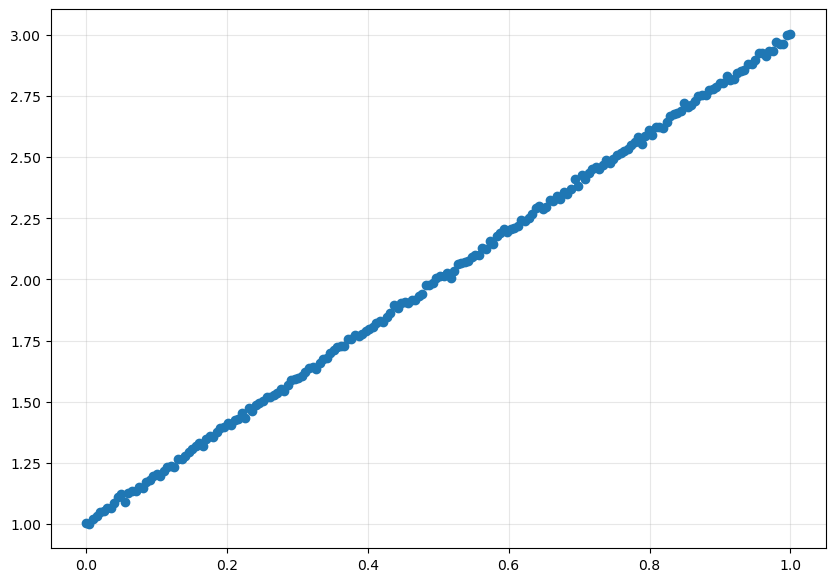

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

N = 200
X = np.linspace(0, 1, N) # equivalent to i/N
Y = 2 * X + 1 + np.random.normal(0, 0.01, size=X.shape)

# Visualize it
plt.figure(figsize=(10, 7))
plt.plot(X, Y, 'o')
plt.grid(alpha=0.3)
plt.show()

1. Implement the MSE loss:
   
   $$
   \mathcal L(\Theta)=\frac{1}{N}\sum_{i=1}^N (f_\Theta(x^{(i)}) - y^{(i)})^2.
   $$


In [3]:
def l(Theta, X, Y):
    return np.mean(np.square(Theta[0] + Theta[1]*X - Y))  

def gradient(Theta, X, Y):
    N = len(X)
    g1 = 2 * np.mean(Theta[0] + Theta[1]*X - Y)
    g2 = 2 / N * np.dot(Theta[0] + Theta[1]*X - Y, X)
    return np.array([g1, g2])

def GD(l, grad_l, X, Y, theta_0, maxit, eta=1e-2, tolL=1e-6, tolTheta=1e-6):
    loss_history = []
    theta_history = []

    # GD step
    for k in range(maxit):
        theta = theta_0 - eta * grad_l(theta_0, X, Y)

        if(np.linalg.norm(grad_l(theta, X, Y))<tolL or (np.linalg.norm(theta-theta_0)<tolTheta)):
            break

        loss_history.append(l(theta, X, Y))
        theta_history.append(theta_0)

        theta_0 = theta
    return theta, k, loss_history, theta_history

def SGD(l, grad_l, X, Y, Theta0, lr=1e-2, batch_size=32, epochs=10):
    epoch_loss = []
    epoch_theta_history = []

    Theta = Theta0
    for epoch in range(epochs):
        shuffle_idx = np.random.permutation(len(X))
        N = len(X)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])
            Theta -= lr * grad

    
        epoch_loss.append(l(Theta, X, Y))
        epoch_theta_history.append(Theta.copy())

    return Theta, epoch, epoch_loss, epoch_theta_history

2. Implement **full GD** and **SGD** (mini-batch) using batch sizes:
   - $N_{\text{batch}} = 1$,
   - $N_{\text{batch}} = 10$,
   - $N_{\text{batch}} = 50$,
   - $N_{\text{batch}} = N$ (this recovers GD).

In [4]:
batch_sizes = [1,10,50,N]

results = pd.DataFrame([],columns=['model','batch_size', 'final_loss', 'epochs', 'Theta', 'epoch_loss', 'epoch_theta_history'])

Theta, epochs, epoch_loss, epoch_theta_history = GD(l, gradient, X, Y, np.zeros((2,)), maxit=1000, eta=1e-2, tolL=1e-6, tolTheta=1e-6)
final_loss = l(Theta, X, Y)
results.loc[len(results)] = ['GD', None, final_loss, epochs, Theta, epoch_loss, epoch_theta_history]

for batch_size in batch_sizes:
    Theta0 = np.zeros((2,))
    Theta, epochs, epoch_loss, epoch_theta_history = SGD(l, gradient, X, Y, Theta0, lr=1e-2, batch_size=batch_size, epochs=1000)
    final_loss = l(Theta, X, Y)
    results.loc[len(results)] = ['SGD', batch_size, final_loss, epochs, Theta, epoch_loss, epoch_theta_history]

display(results.sort_values(by='final_loss'))

,model,batch_size,final_loss,epochs,Theta,epoch_loss,epoch_theta_history
2,SGD,10,0.000093,999,"[0.9990528377289504, 2.0005194281289254]","[1.613682012125931, 0.6402250800310789, 0.2893...","[[0.6322704858000299, 0.3751440826735151], [1...."
1,SGD,1,0.000094,999,"[0.9992385417555776, 2.0008710821758506]","[0.06757752758772897, 0.03937217701429339, 0.0...","[[1.488482520729229, 1.1219398902370268], [1.3..."
3,SGD,50,0.000096,999,"[1.0020752256206997, 1.9949361570046087]","[3.548815741848946, 2.9090105643638253, 2.3876...","[[0.15381576957340964, 0.09019185048557049], [..."
4,SGD,200,0.007864,999,"[1.1605889419825357, 1.6989528533122311]","[4.122570790423419, 3.9214053381157417, 3.7302...","[[0.03998684487260865, 0.02336114758780377], [..."
0,GD,None,0.007864,999,"[1.1605889419825361, 1.6989528533122307]","[4.122570790423419, 3.9214053381157417, 3.7302...","[[0.0, 0.0], [0.03998684487260865, 0.023361147..."


In [5]:
batch_sizes = [1,10,50,N]

results = pd.DataFrame([],columns=['batch_size', 'final_loss', 'epochs', 'Theta', 'epoch_loss', 'epoch_theta_history'])
for batch_size in batch_sizes:
    Theta0 = np.zeros((2,))
    Theta, epochs, epoch_loss, epoch_theta_history = SGD(l, gradient, X, Y, Theta0, lr=1e-2, batch_size=batch_size, epochs=1000)
    final_loss = l(Theta, X, Y)
    results.loc[len(results)] = [batch_size, final_loss, epochs, Theta, epoch_loss, epoch_theta_history]

display(results.sort_values(by='final_loss'))

,batch_size,final_loss,epochs,Theta,epoch_loss,epoch_theta_history
1,10,0.000093,999,"[0.9990748130696583, 2.0005246000974846]","[1.622340991319915, 0.6424637404785247, 0.2875...","[[0.6271500868659844, 0.37750866281632606], [0..."
0,1,0.000094,999,"[0.9996537570193778, 2.0009910519628265]","[0.06705168014419835, 0.03930767994175392, 0.0...","[[1.4709414727429349, 1.1141025711718253], [1...."
2,50,0.000096,999,"[1.0020743114925015, 1.9949361189127046]","[3.5490578801753245, 2.9092409915563344, 2.387...","[[0.1537214738865318, 0.09023775609000617], [0..."
3,200,0.007864,999,"[1.160588941982536, 1.6989528533122307]","[4.122570790423419, 3.9214053381157417, 3.7302...","[[0.03998684487260865, 0.02336114758780377], [..."


3. Plot for each method:
   - the loss curve (loss vs epoch),
   - the trajectory of parameters $(\Theta_0,\Theta_1)$ in the 2D parameter space. This is similar to what you did in the previous homework: simply plot the value of $\Theta_0^{(k)}$ and $\Theta_1^{(k)}$ for all the $k$s in a 2-dimensional plot.

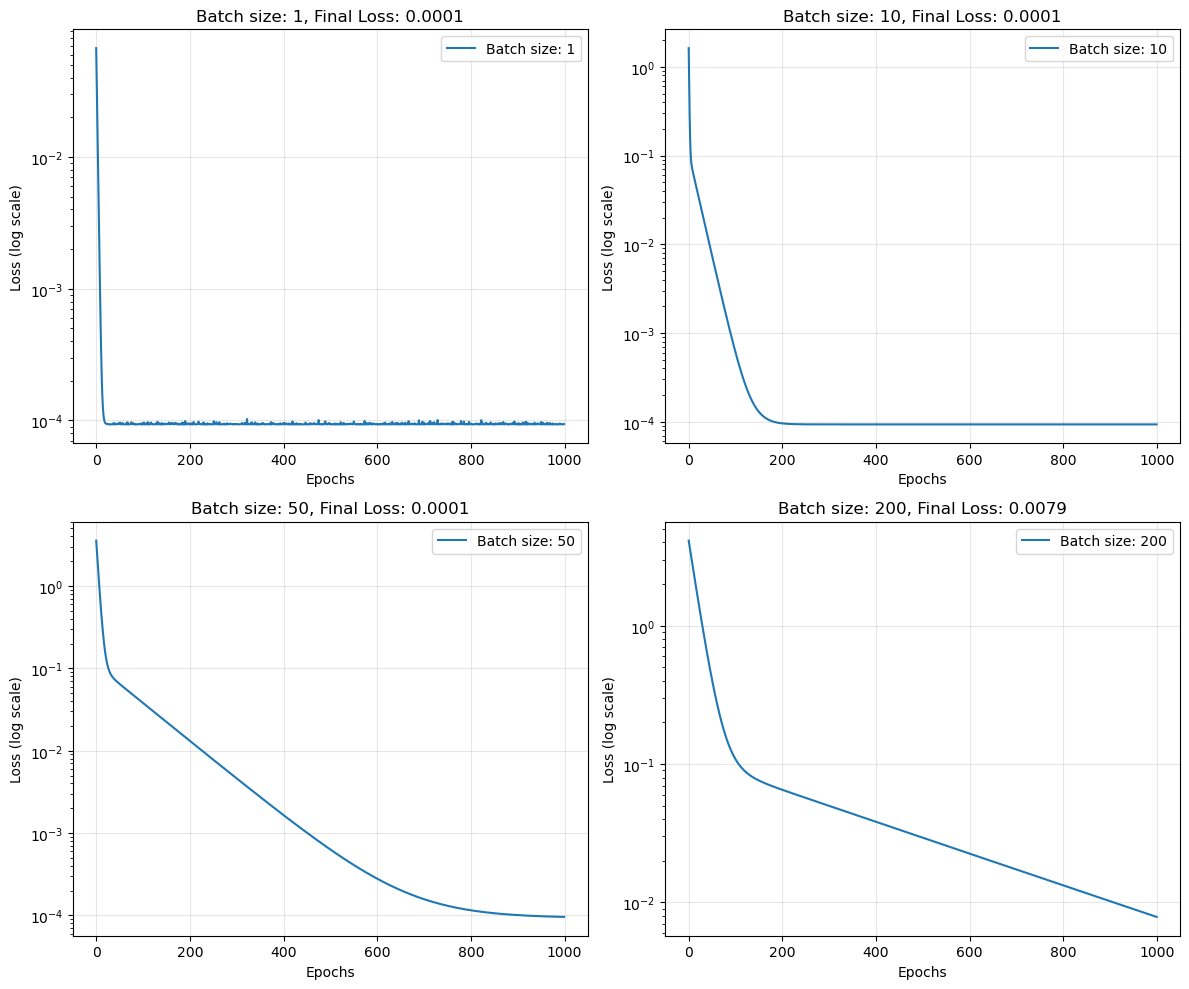

In [6]:
n_plots = len(results)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()
for index, row in results.iterrows():
    axes[index].plot(row['epoch_loss'], label=f"Batch size: {row['batch_size']}")
    axes[index].set_yscale('log')
    axes[index].set_xlabel("Epochs")
    axes[index].set_ylabel("Loss (log scale)")
    axes[index].legend()
    axes[index].grid(alpha=0.3)
    axes[index].set_title(f"Batch size: {row['batch_size']}, Final Loss: {row['final_loss']:.4f}")

plt.tight_layout()
plt.show()

In [7]:
def loss_levelsets(X_data, Y_data, theta_0_lim=(0.5,1.5), theta_1_lim=(1.5,2.5), ngrid=400, 
                   ncontours=12, title=None):
    theta_0_vals = np.linspace(theta_0_lim[0], theta_0_lim[1], ngrid)
    theta_1_vals = np.linspace(theta_1_lim[0], theta_1_lim[1], ngrid)
    Theta0_grid, Theta1_grid = np.meshgrid(theta_0_vals, theta_1_vals)
    
    Z = np.mean((Theta0_grid[:,:,np.newaxis] + Theta1_grid[:,:,np.newaxis] * X_data - Y_data)**2, axis=2)
    
    cs = plt.contour(Theta0_grid, Theta1_grid, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_0$ (bias)')
    plt.ylabel(r'$\theta_1$ (slope)')
    plt.grid(alpha=0.2)

    # ensure axis bounds are set so subsequent plotting is clipped to these limits
    plt.xlim(theta_0_lim)
    plt.ylim(theta_1_lim)

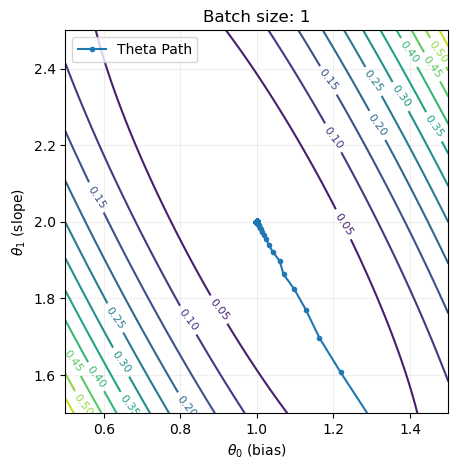

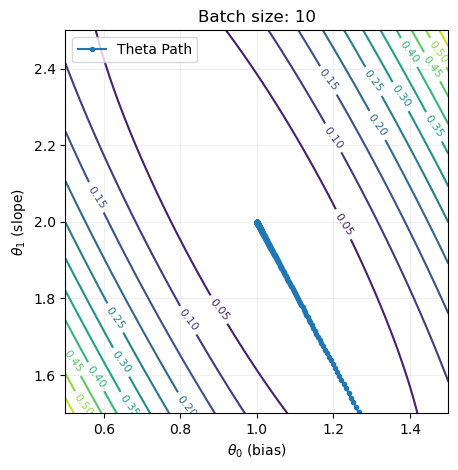

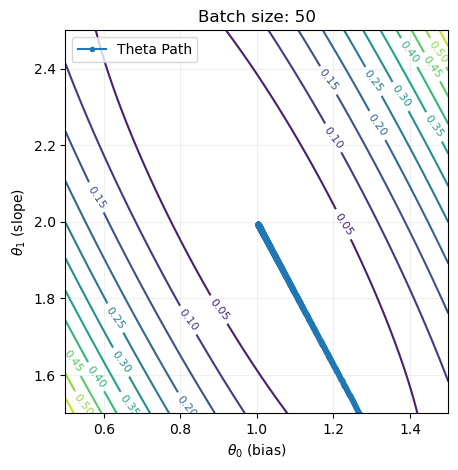

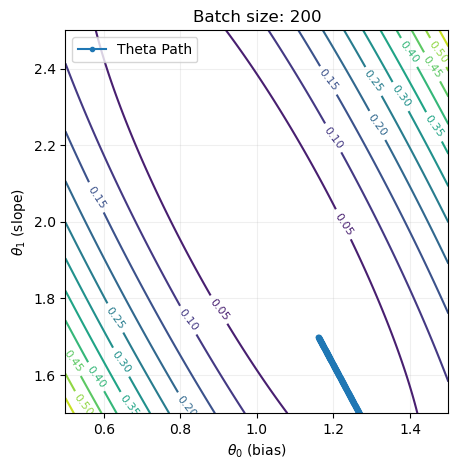

In [8]:
# plot epoch theta history
for index, row in results.iterrows():
    loss_levelsets(X, Y, title=f"Batch size: {row['batch_size']}")
    plt.plot(
        [theta[0] for theta in row['epoch_theta_history']],
        [theta[1] for theta in row['epoch_theta_history']],
        '-o', markersize=3, label='Theta Path'
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


4. Discuss:
   - Why GD is smooth but slow for large $N$,
   - Why SGD is noisy but progresses faster,
   - How batch size affects the noise level and convergence stability.

## Exercise 2: Variance of the Stochastic Gradient (1D Experiment)

Fix a parameter vector $\Theta$, and repeatedly draw random mini-batches of the same size.

1. Choose batch sizes:
   
   $$
   N_{\text{batch}} \in \{1, 5, 20, N\}.
   $$


2. At the **same** $\Theta$, compute:
   
   $$
   g_k = \nabla_\Theta \mathcal L(\Theta; \mathcal M_k)
   $$

   for 100 randomly sampled batches $\mathcal M_k$.

3. For each batch size, compute the empirical variance:
   
   $$
   \mathrm{Var}(g) = \frac{1}{100}\sum_{k=1}^{100} \|g_k - \bar g\|^2,
   $$

   where $\bar{g}$ is the average of the $g_k$s, defined as:

   $$
   \bar{g} = \frac{1}{100} \sum_{k=1}^{100} g_k.
   $$


In [9]:
fixed_theta = np.array([1.0, 2.0])

batch_sizes = [1,5,20,N]

monte_carlo_variance_estimates = pd.DataFrame([], columns=['batch_size', 'grad_mean', 'grad_variance'])

for batch_size in batch_sizes:
    n_of_iterations = 100
    grads = []
    for i in range(n_of_iterations):
        shuffle_idx = np.random.permutation(len(X))   
        batch_idx = shuffle_idx[:batch_size]
        grad = gradient(fixed_theta, X[batch_idx], Y[batch_idx])
        grads.append(grad)
    grads = np.array(grads)
    grad_mean =  1/n_of_iterations * np.sum(grads, axis=0)  
    grad_variance = 1/n_of_iterations * np.sum(np.linalg.norm(grads - grad_mean, axis=1)**2) 
    monte_carlo_variance_estimates.loc[len(monte_carlo_variance_estimates)] = [batch_size, grad_mean, grad_variance]

display(monte_carlo_variance_estimates.sort_values(by='grad_variance', ascending=False))

,batch_size,grad_mean,grad_variance
0,1,"[0.0014150220994054853, 0.0006416053580354602]",5.272862e-04
1,5,"[0.001372697180764428, 0.00046057614380477465]",9.609348e-05
2,20,"[0.0017520471058240735, 0.0007287227654324294]",1.949549e-05
3,200,"[0.0013155127391348545, 0.0005686583050499015]",5.982796e-36


4. Plot the variance as a function of the batch size.

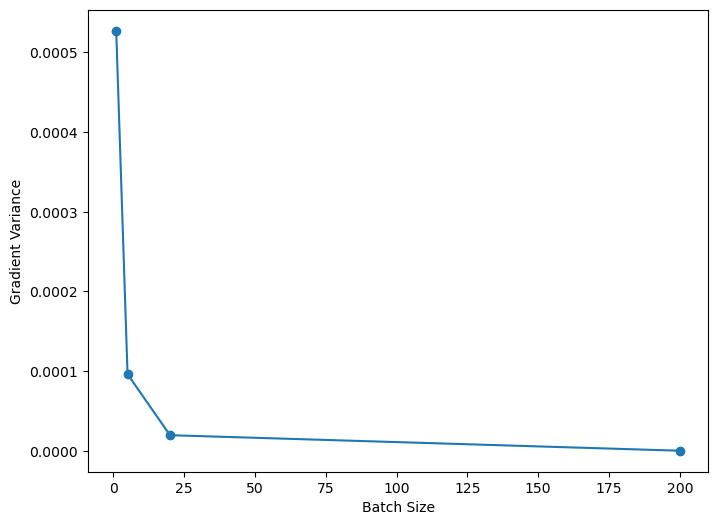

In [10]:
plt.figure(figsize=(8,6))
plt.plot(monte_carlo_variance_estimates['batch_size'], monte_carlo_variance_estimates['grad_variance'], '-o')
plt.xlabel("Batch Size")
plt.ylabel("Gradient Variance")
plt.show()

5. Comment:
   - Why the variance decreases with larger batches,
   - Why SGD becomes more stable as $N_{\text{batch}}$ increases,
   - The trade-off between stability and computational cost.

## Exercise 3: SGD in 2D

We now study SGD on the 2D non-convex function:

$$
\mathcal{L}(\Theta_1,\Theta_2) = (\Theta_1^2 - 1)^2 + 10(\Theta_2 - \Theta_1^2)^2.
$$

This function has:
- two valleys,
- multiple stationary points,
- strong curvature differences.

In [11]:
def l(Theta):
    return (1 - Theta[0])**2 + 10 * (Theta[1] - Theta[0]**2)**2

def gradient(Theta):
    g1 = -2 * (1 - Theta[0]) - 40 * Theta[0] * (Theta[1] - Theta[0]**2)
    g2 = 20 * (Theta[1] - Theta[0]**2)
    return np.array([g1, g2])

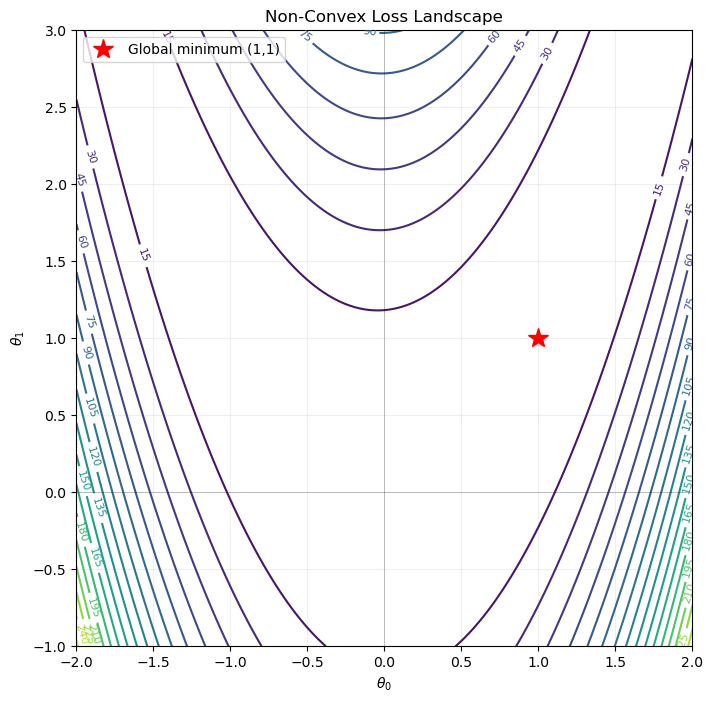

In [12]:
# Visualize the loss landscape
def plot_nonconvex_levelsets(theta_0_lim=(-2, 2), theta_1_lim=(-1, 3), ngrid=400, ncontours=20, title=None):
    theta_0_vals = np.linspace(theta_0_lim[0], theta_0_lim[1], ngrid)
    theta_1_vals = np.linspace(theta_1_lim[0], theta_1_lim[1], ngrid)
    Theta0_grid, Theta1_grid = np.meshgrid(theta_0_vals, theta_1_vals)
    
    # Compute loss for each grid point
    Z = (1 - Theta0_grid)**2 + 10 * (Theta1_grid - Theta0_grid**2)**2
    
    cs = plt.contour(Theta0_grid, Theta1_grid, Z, levels=ncontours, cmap='viridis')
    plt.clabel(cs, inline=True, fontsize=8)
    
    # Mark the global minimum at (1, 1)
    plt.plot(1, 1, 'r*', markersize=15, label='Global minimum (1,1)')
    
    plt.axhline(0, lw=0.5, color='k', alpha=0.3)
    plt.axvline(0, lw=0.5, color='k', alpha=0.3)
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$')
    plt.grid(alpha=0.2)
    plt.xlim(theta_0_lim)
    plt.ylim(theta_1_lim)
    plt.legend()

# Plot the landscape
plt.figure(figsize=(10, 8))
plot_nonconvex_levelsets(title='Non-Convex Loss Landscape')
plt.show()

1. Treat $\Theta = (\Theta_1,\Theta_2)$ as a “parameter vector” updated by SGD:
   
   $$
   \Theta_{k+1} = \Theta_k - \eta\, g_k,
   $$

   where the ``gradient batch'' $g_k$ is simulated by adding noise to the gradient:
   
   $$
   g_k = \nabla \mathcal{L}(\Theta_k) + \varepsilon_k, \qquad \varepsilon_k \sim \mathcal{N}(0, \sigma^2I),
   $$

   where $\sigma^2$ is called **noise level** and represent the variance of the noise. Try different values of $\sigma^2$ to answer the following questions. *Note: $\sigma^2$ should always be lower than 1*. 

In [13]:
def SGD_with_noise(L, grad_L, theta_0, lr=1e-3, noise_level=0.1, epochs=1000):
    """
    SGD with simulated gradient noise.
    
    At each iteration, the gradient batch is:
        g_batch = grad_L(theta) + N(0, noise_level^2 * I)
    """
    theta = theta_0.copy()
    theta_history = [theta.copy()]
    loss_history = [L(theta)]
    
    for epoch in range(epochs):
        # Compute true gradient
        g_true = grad_L(theta)
        
        # Add Gaussian noise to simulate stochastic gradient
        noise = np.random.normal(0, noise_level, size=theta.shape)
        g_batch = g_true + noise
        
        # SGD update
        theta = theta - lr * g_batch
        
        theta_history.append(theta.copy())
        loss_history.append(L(theta))

        if np.linalg.norm(theta) > 1e5:
            break
    
    return theta, theta_history, loss_history

2. Plot:
   - level sets of $\mathcal{L}(\Theta_1,\Theta_2)$,
   - trajectories of SGD for different noise levels and step sizes.

In [14]:
from sklearn.model_selection import ParameterGrid

starting_theta = np.array([0.0, 0.0])
etas = [0.1, 0.01, 0.001, 0.0001]
noise_levels = [0.05, 0.1, 0.5, 1.0]

param_grid = ParameterGrid({'eta': etas, 'noise_level': noise_levels})
configurations = list(param_grid)

In [15]:
SGD_simulations = pd.DataFrame([], columns=['eta', 'noise_level', 'final_theta', 'final_loss', 'theta_history', 'loss_history'])

for config in configurations:
    eta = config['eta']
    noise_level = config['noise_level']
    
    theta0 = np.array([0.0, 0.0])
    theta_final, theta_history, loss_history = SGD_with_noise(
        L=l, grad_L=gradient, theta_0=theta0, lr=eta, noise_level=noise_level, epochs=5000
    )
    
    final_loss = l(theta_final)
    SGD_simulations.loc[len(SGD_simulations)] = [eta, noise_level, theta_final, final_loss, theta_history, loss_history]

display(SGD_simulations[['eta', 'noise_level', 'final_loss','final_theta']].sort_values(by='final_loss'))

,eta,noise_level,final_loss,final_theta
4,0.0100,0.05,9.366085e-06,"[1.0007326931199554, 1.0005262823931913]"
5,0.0100,0.10,1.911504e-05,"[1.0030798533476404, 1.007150494358005]"
6,0.0100,0.50,1.041283e-04,"[0.9986077625969335, 1.0004141796899464]"
11,0.0010,1.00,8.181117e-04,"[0.9779708828449323, 0.9506579083274124]"
8,0.0010,0.05,2.035267e-03,"[0.955334229874974, 0.9106576036569252]"
10,0.0010,0.50,2.084826e-03,"[0.9563931889591754, 0.9104069050531178]"
9,0.0010,0.10,2.169753e-03,"[0.9536852143884008, 0.9079440725687503]"
7,0.0100,1.00,4.376071e-03,"[1.043173875862208, 1.1040613025434716]"
14,0.0001,0.50,2.452754e-01,"[0.511569542012025, 0.2357977032615872]"
13,0.0001,0.10,2.466320e-01,"[0.5098604187180621, 0.23466901111814384]"


In [16]:
SGD_simulations = pd.DataFrame([], columns=['eta', 'noise_level', 'final_theta', 'final_loss', 'theta_history', 'loss_history'])

for config in configurations:
    eta = config['eta']
    noise_level = config['noise_level']
    
    theta0 = np.array([0.0, 0.0])
    theta_final, theta_history, loss_history = SGD_with_noise(
        L=l, grad_L=gradient, theta_0=theta0, lr=eta, noise_level=noise_level, epochs=5000
    )
    
    final_loss = l(theta_final)
    SGD_simulations.loc[len(SGD_simulations)] = [eta, noise_level, theta_final, final_loss, theta_history, loss_history]

display(SGD_simulations[['eta', 'noise_level', 'final_loss','final_theta']].sort_values(by='final_loss'))

,eta,noise_level,final_loss,final_theta
4,0.0100,0.05,5.614697e-06,"[1.0017336833192403, 1.0029595847566208]"
5,0.0100,0.10,6.886555e-05,"[0.9926533310245641, 0.9865809638107029]"
9,0.0010,0.10,1.929407e-03,"[0.9566146337992373, 0.9129409057784593]"
8,0.0010,0.05,2.167965e-03,"[0.9537848196500261, 0.90791320956293]"
7,0.0100,1.00,2.343014e-03,"[0.9837914141432909, 0.9822687780572023]"
10,0.0010,0.50,2.995486e-03,"[0.9453111619502026, 0.8929336814504336]"
11,0.0010,1.00,3.106772e-03,"[0.9452973442761134, 0.8969692437991666]"
6,0.0100,0.50,6.268670e-03,"[0.9775360095025518, 0.9315682357856818]"
13,0.0001,0.10,2.469566e-01,"[0.5093911976300617, 0.23446014961791745]"
12,0.0001,0.05,2.471462e-01,"[0.5092925908744792, 0.23417481256769337]"


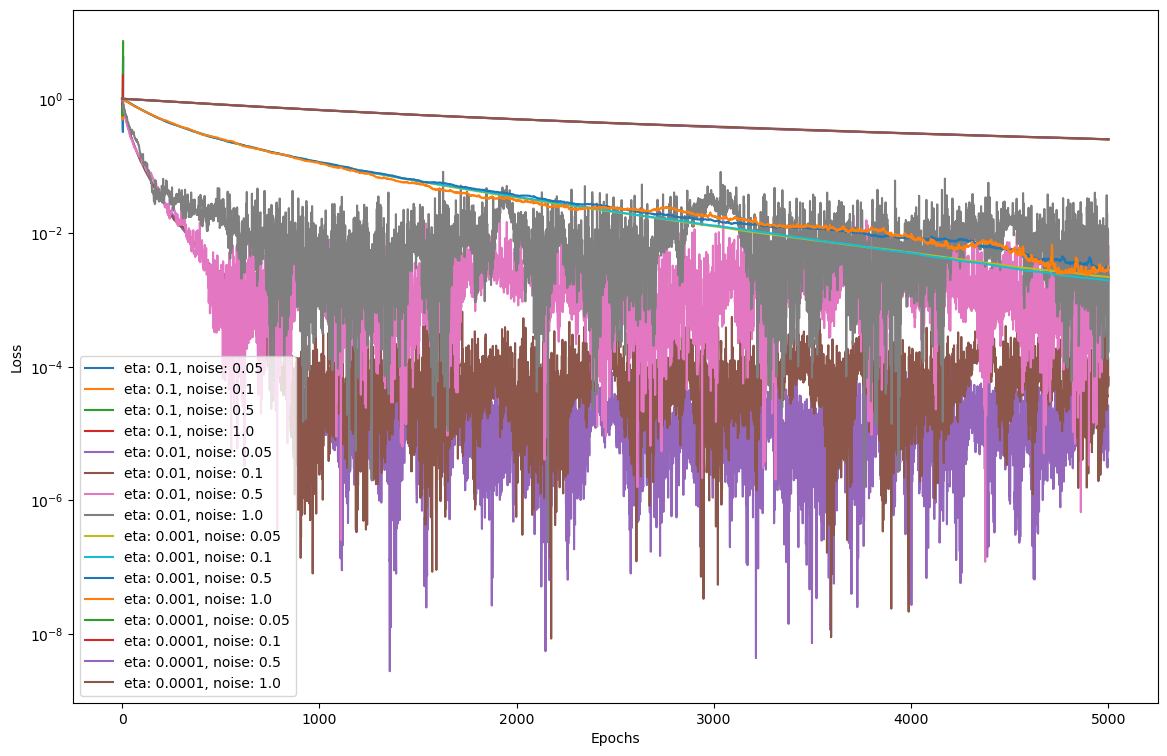

In [17]:
# Plot loss
plt.figure(figsize=(14, 9))
for index, row in SGD_simulations.iterrows():
    loss = np.array(row['loss_history'])
    idx = np.where(loss < 1e1)[0]
    if idx.size:
        plt.plot(idx, loss[idx], label=f"eta: {row['eta']}, noise: {row['noise_level']}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale('log')
plt.legend()
plt.show()
# ...existing code...

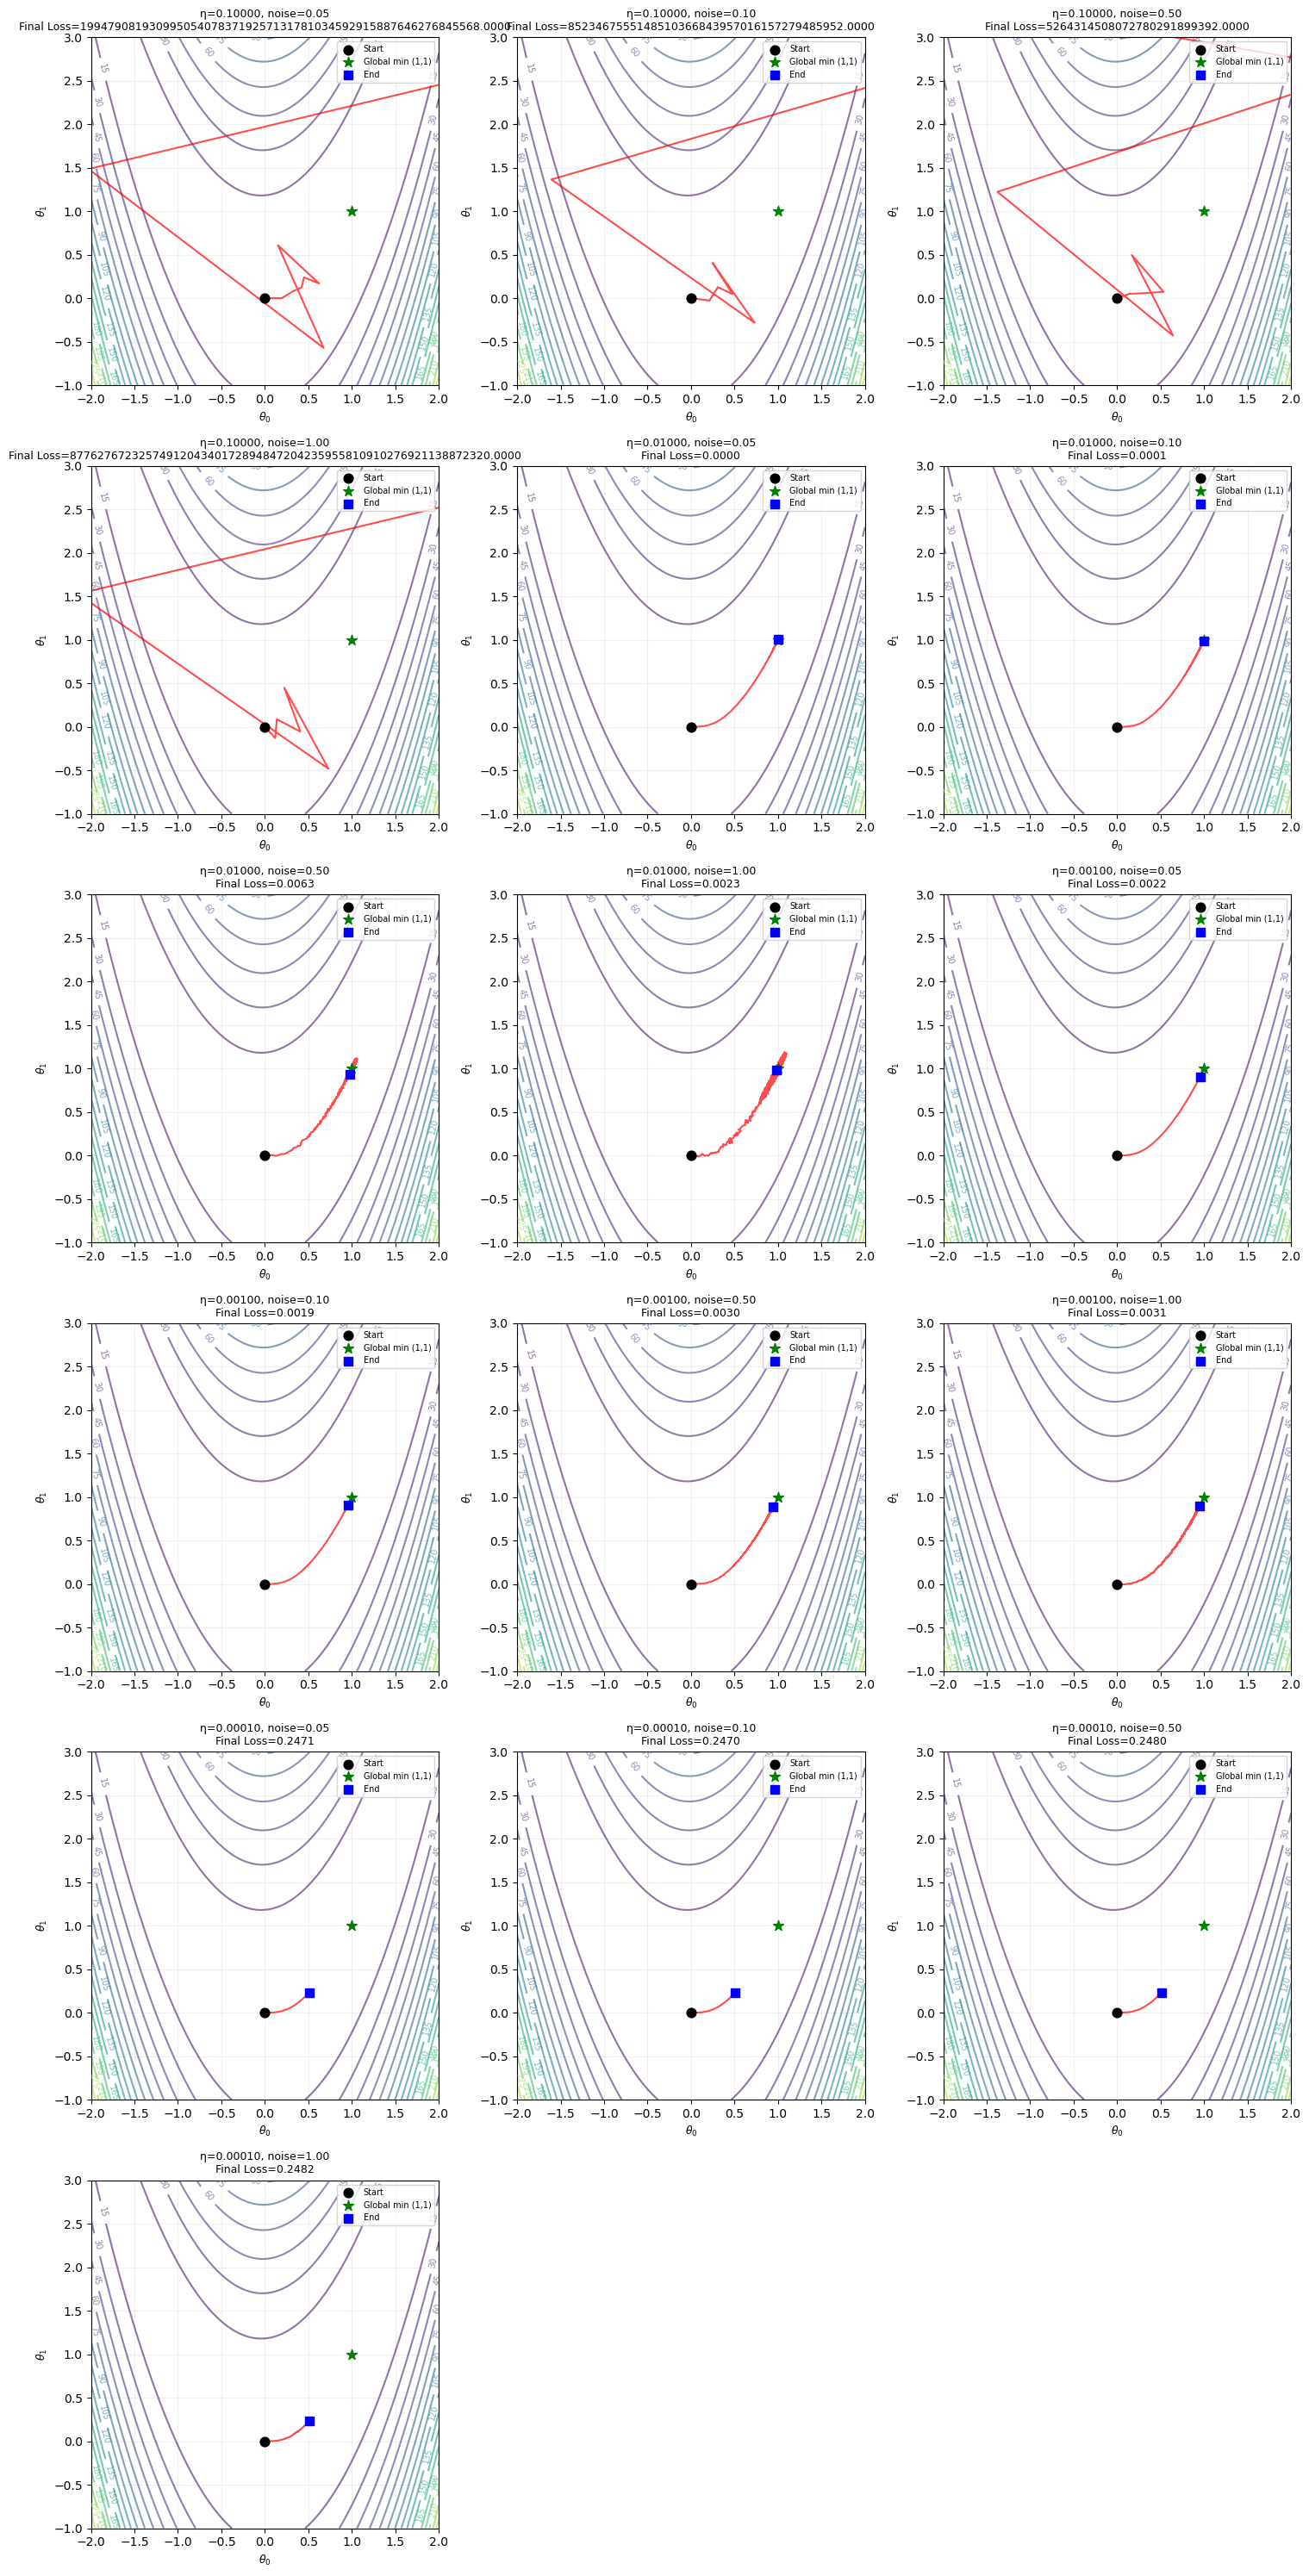

In [18]:
# Plot trajectories for all configurations
n_plots = len(configurations)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for ax, (idx, row) in zip(axes, SGD_simulations.iterrows()):
    eta = row['eta']
    noise_level = row['noise_level']
    theta_history = np.array(row['theta_history'])
    
    # Draw level sets
    xs = np.linspace(-2, 2, 400)
    ys = np.linspace(-1, 3, 400)
    X_grid, Y_grid = np.meshgrid(xs, ys)
    Z = (1 - X_grid)**2 + 10 * (Y_grid - X_grid**2)**2
    cs = ax.contour(X_grid, Y_grid, Z, levels=20, cmap='viridis', alpha=0.6)
    ax.clabel(cs, inline=True, fontsize=7)
    
    # Plot trajectory
    ax.plot(theta_history[:, 0], theta_history[:, 1], 'r-', alpha=0.7, linewidth=1.5)
    ax.scatter(theta_history[0, 0], theta_history[0, 1], color='black', s=60, marker='o', zorder=5, label='Start')
    ax.scatter(1, 1, color='green', s=80, marker='*', zorder=5, label='Global min (1,1)')
    ax.scatter(theta_history[-1, 0], theta_history[-1, 1], color='blue', s=60, marker='s', zorder=5, label='End')
    
    ax.legend(loc='upper right', fontsize=7)
    ax.set_title(f'η={eta:.5f}, noise={noise_level:.2f}\nFinal Loss={row["final_loss"]:.4f}', fontsize=9)
    ax.set_xlabel(r'$\theta_0$', fontsize=9)
    ax.set_ylabel(r'$\theta_1$', fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)

# Hide empty subplots
for ax in axes[n_plots:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Exercise 4: An ML Project with SGD

For the final exercise, you will train a simple machine learning model using SGD on a real prediction task. 
To begin, download the Kaggle dataset: https://www.kaggle.com/datasets/mirichoi0218/insurance.

It contains approximately 1300 samples, and its associated task is to predict **individual medical insurance cost** based on numerical features:

- `age`
- `bmi`
- `children`  

The task is:

$$
\text{charges} \approx f_\Theta(\text{age},\text{bmi},\text{children}).
$$

We use a simple linear model:

$$
f_\Theta(x) = \Theta^T \tilde{x}.
$$

In [19]:
df0 = pd.read_csv('./insurance.csv')
df0.shape

(1338, 7)

In [20]:
df0.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


1. Load & preprocess the dataset
   - Download `insurance.csv` from Kaggle.
   - Select numerical columns:  
     `["age", "bmi", "children"]`.
   - Standardize each feature (mean 0, variance 1).
   - Standardize the target `"charges"`.
   - Add a bias column.
  

In [21]:
df = df0[['age','bmi','children']]
Y = df0['charges'].to_numpy()

df.head()

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0


In [22]:
X = df.to_numpy()
X = (X - X.mean(axis=0)) / X.std(axis=0) 
X = np.hstack([np.ones((X.shape[0], 1)), X]) 
Y = (Y - Y.mean()) / Y.std()

2. Consider the MSE loss:

   $$
   \mathcal{L}(\Theta)=\frac{1}{N}\sum_{i=1}^N (\Theta^T \tilde{x}^{(i)} - \tilde{y}^{(i)})^2.
   $$

   Implement:
   - Full GD  
   - SGD with batch sizes 1, 10, 50

   Use a fixed learning rate $\eta=10^{-2}$ and a fixed number of epochs (equivalently, a fixed amount of maximum iterations for GD) of your choice.

In [23]:
def l(Theta, X_data=X, Y_data=Y):
    N = len(Y_data)
    predictions = X_data @ Theta
    return (1/N) * np.sum((predictions - Y_data)**2)

def gradient(Theta, X_data=X, Y_data=Y):
    N = len(Y_data)
    predictions = X_data @ Theta
    errors = predictions - Y_data
    grad = (2/N) * (X_data.T @ errors)
    return grad

def SGD(l, grad_l, X, Y, Theta0, lr=1e-2, batch_size=32, epochs=10):
    epoch_loss = []
    epoch_theta_history = []
    epoch_l2_norm_history = []

    Theta = Theta0
    for epoch in range(epochs):
        shuffle_idx = np.random.permutation(len(X))
        N = len(X)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])
            Theta -= lr * grad

    
        epoch_loss.append(l(Theta, X, Y))
        epoch_theta_history.append(Theta.copy())
        epoch_l2_norm_history.append(np.linalg.norm(Theta))

    return Theta, epoch, epoch_loss, epoch_theta_history, epoch_l2_norm_history

In [24]:
N = X.shape[0]

batch_sizes = [1,10,50,N]

results = pd.DataFrame([],columns=['batch_size', 'final_loss', 'epochs', 'Theta', 'L2_norm_history','epoch_loss', 'epoch_theta_history'])
for batch_size in batch_sizes:
    Theta0 = np.zeros((X.shape[1],))
    Theta, epochs, epoch_loss, epoch_theta_history, epoch_l2_norm_history = SGD(l, gradient, X, Y, Theta0, lr=1e-2, batch_size=batch_size, epochs=1000)
    final_loss = l(Theta, X, Y)
    results.loc[len(results)] = [batch_size, final_loss, epochs, Theta, epoch_l2_norm_history, epoch_loss, epoch_theta_history]

In [25]:
display(results[['batch_size','final_loss','Theta']].sort_values(by='final_loss').style.format({'final_loss':'{:.6f}','Theta':lambda x: np.array2string(x, precision=4)}))

,batch_size,final_loss,Theta
3,1338,0.879902,[1.4108e-17 2.7844e-01 1.6723e-01 5.4040e-02]
2,50,0.879926,[-0.0041 0.2772 0.1658 0.0559]
1,10,0.881418,[0.0288 0.2845 0.1921 0.0518]
0,1,0.936925,[0.0833 0.0651 0.2575 0.0355]


3. Compare GD and SGD
   For each method:

   - Plot the loss vs epoch.
   - Plot the L2 norm of the **full gradient** $\|\nabla \mathcal{L}(\Theta_k)\|$ measured at the end of every epoch.
   - Report the final learned parameters.

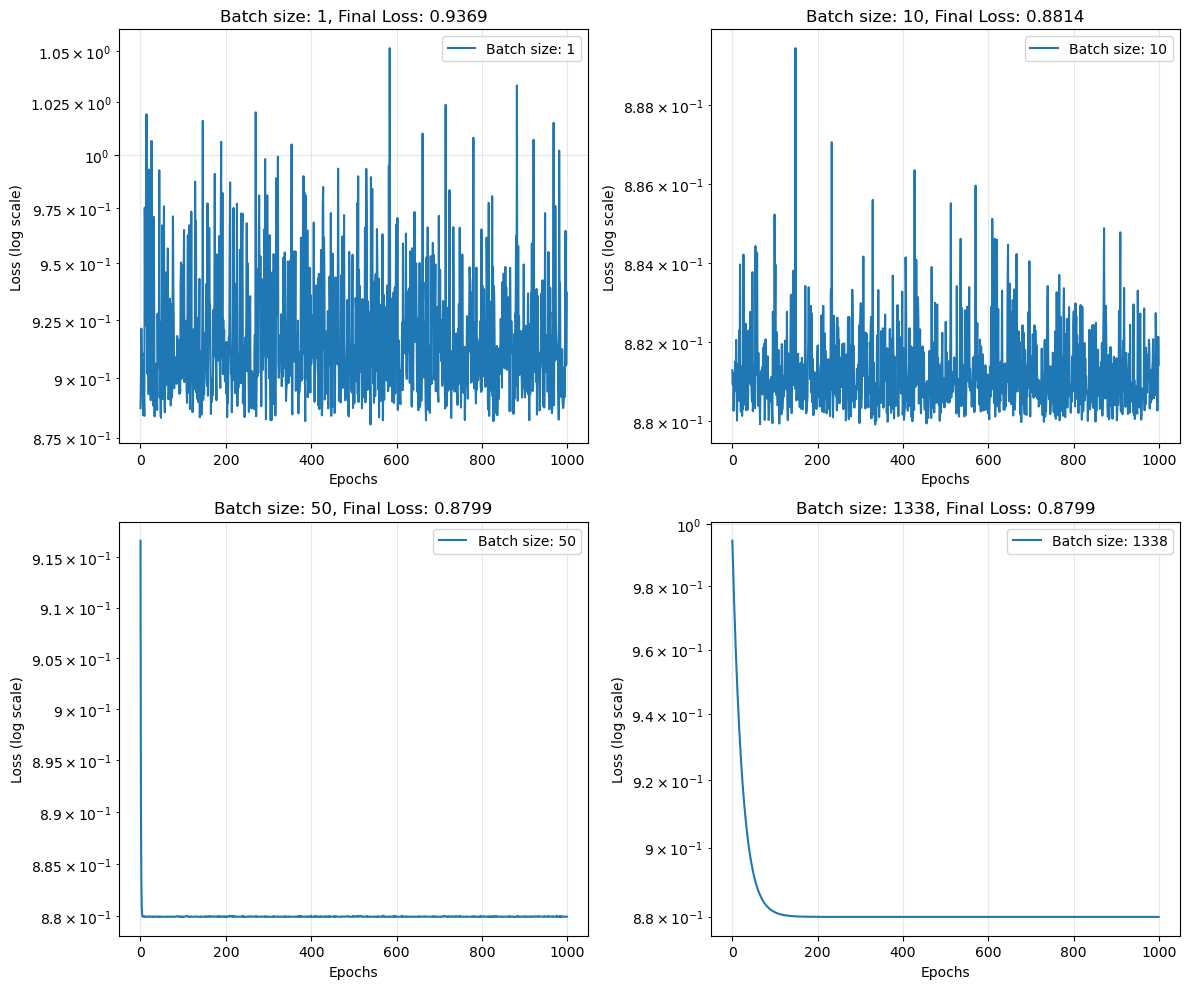

In [26]:
n_plots = len(results)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()
for index, row in results.iterrows():
    axes[index].plot(row['epoch_loss'], label=f"Batch size: {row['batch_size']}")
    axes[index].set_yscale('log')
    axes[index].set_xlabel("Epochs")
    axes[index].set_ylabel("Loss (log scale)")
    axes[index].legend()
    axes[index].grid(alpha=0.3)
    axes[index].set_title(f"Batch size: {row['batch_size']}, Final Loss: {row['final_loss']:.4f}")

plt.tight_layout()
plt.show()

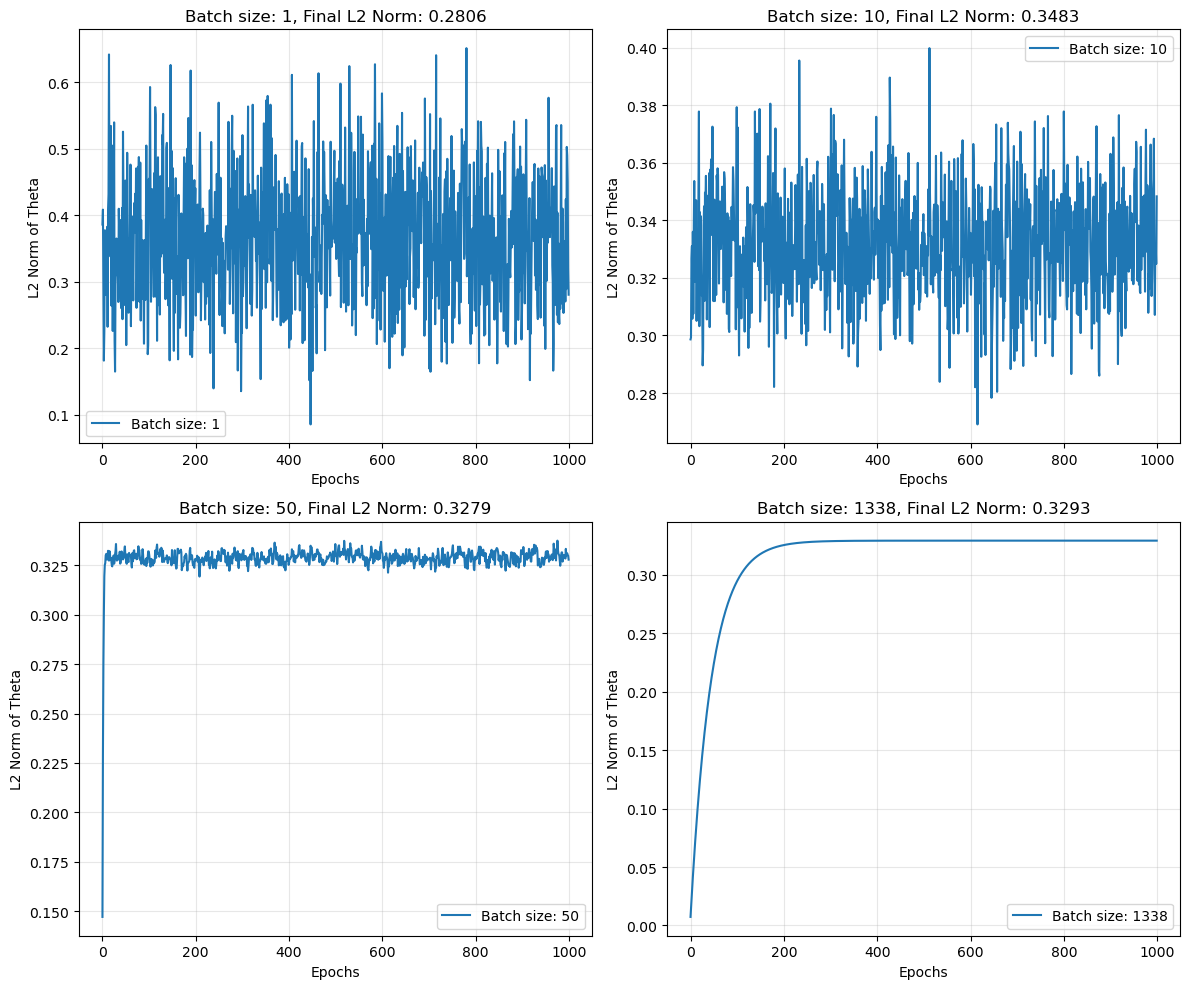

In [27]:
# print the L2 norm history for each batch size
n_plots = len(results)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 *n_rows))
axes = axes.flatten()
for index, row in results.iterrows():
    axes[index].plot(row['L2_norm_history'], label=f"Batch size: {row['batch_size']}")
    axes[index].set_xlabel("Epochs")
    axes[index].set_ylabel("L2 Norm of Theta")
    axes[index].legend()
    axes[index].grid(alpha=0.3)
    axes[index].set_title(f"Batch size: {row['batch_size']}, Final L2 Norm: {row['L2_norm_history'][-1]:.4f}")
plt.tight_layout()
plt.show()

4. Discuss:
   - Why GD gives a smooth curve and SGD oscillates.
   - Why larger batches reduce noise but cost more per iteration.
   - Why all methods roughly converge to the same region.
   - Why SGD is more suitable for large datasets, even when noisy.